# Simulation Analysis

This file is to be used to analyse observable quantities of a simulation

In [12]:

import sys
from pathlib import Path

if sys.platform == "darwin":
    proj = "/Users/rileymcnamara/CODE/2025/silicokit/"
    sys.path.insert(0, proj)
else:
    proj = "C:/Users/riley.mcnamara/Documents/code/silicokit/"
    sys.path.insert(0, proj)

from src.growkit.PlotEngine.SimPlotter import SimPlotter
from src.growkit.PlotEngine.CellFieldPlotter import CellFieldPlotter
from src.growkit.Simulator import TumorGrowthSimulator

simulator = TumorGrowthSimulator(proj + "/configs/csc-t-n.yaml")

simulation_data = simulator.load_simulation_data(proj + "/laboratory/saved_simulations/simulation_data.npz")

sim_plotter = SimPlotter(simulation_data)
cell_plotter = CellFieldPlotter(simulation_data, simulator=simulator)


Pre-compiling Numba functions...
Numba functions compiled successfully!
Loading simulation data from C:/Users/riley.mcnamara/Documents/code/silicokit//laboratory/saved_simulations/simulation_data.npz...
Loaded simulation data with 7 saved steps


## Radius Evolution

Calculating tumor radius evolution...


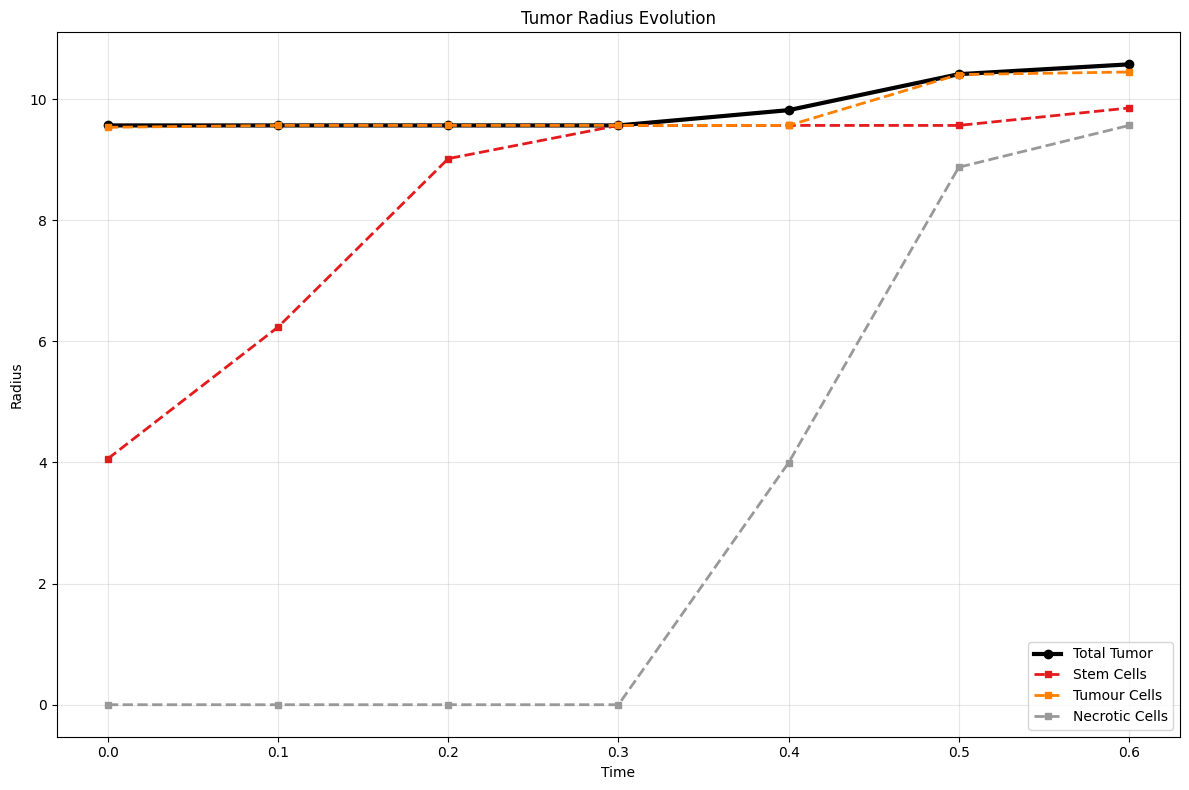

In [13]:
sim_plotter.plot_tumor_radius_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(12, 8), include_individual_populations=True, threshold=0.1, method='contour')

## Population Density Evolution

Calculating population density evolution...


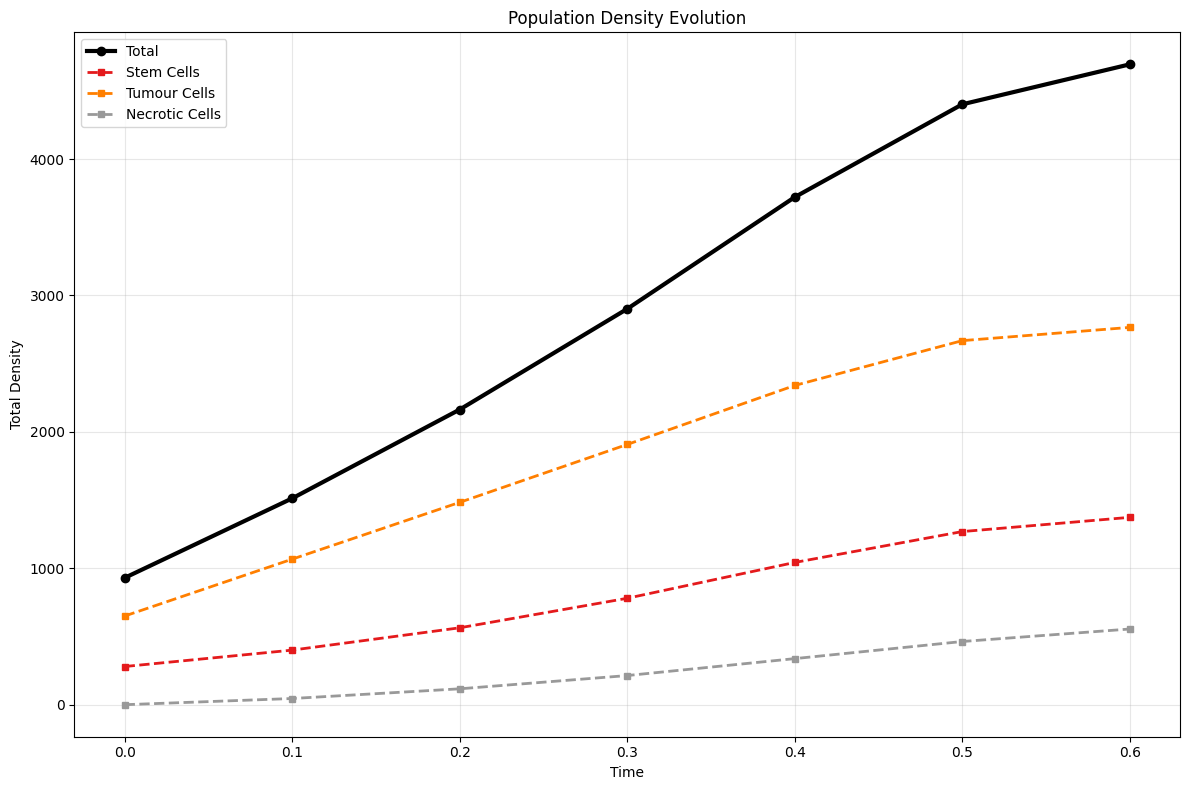

In [14]:
sim_plotter.plot_population_density_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(12, 8), normalize_by_volume=False)

Plotting evolution for population: Stem Cells (index: 0)
Available population labels: ['Stem Cells', 'Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 2, 3, 4, 5, 6]


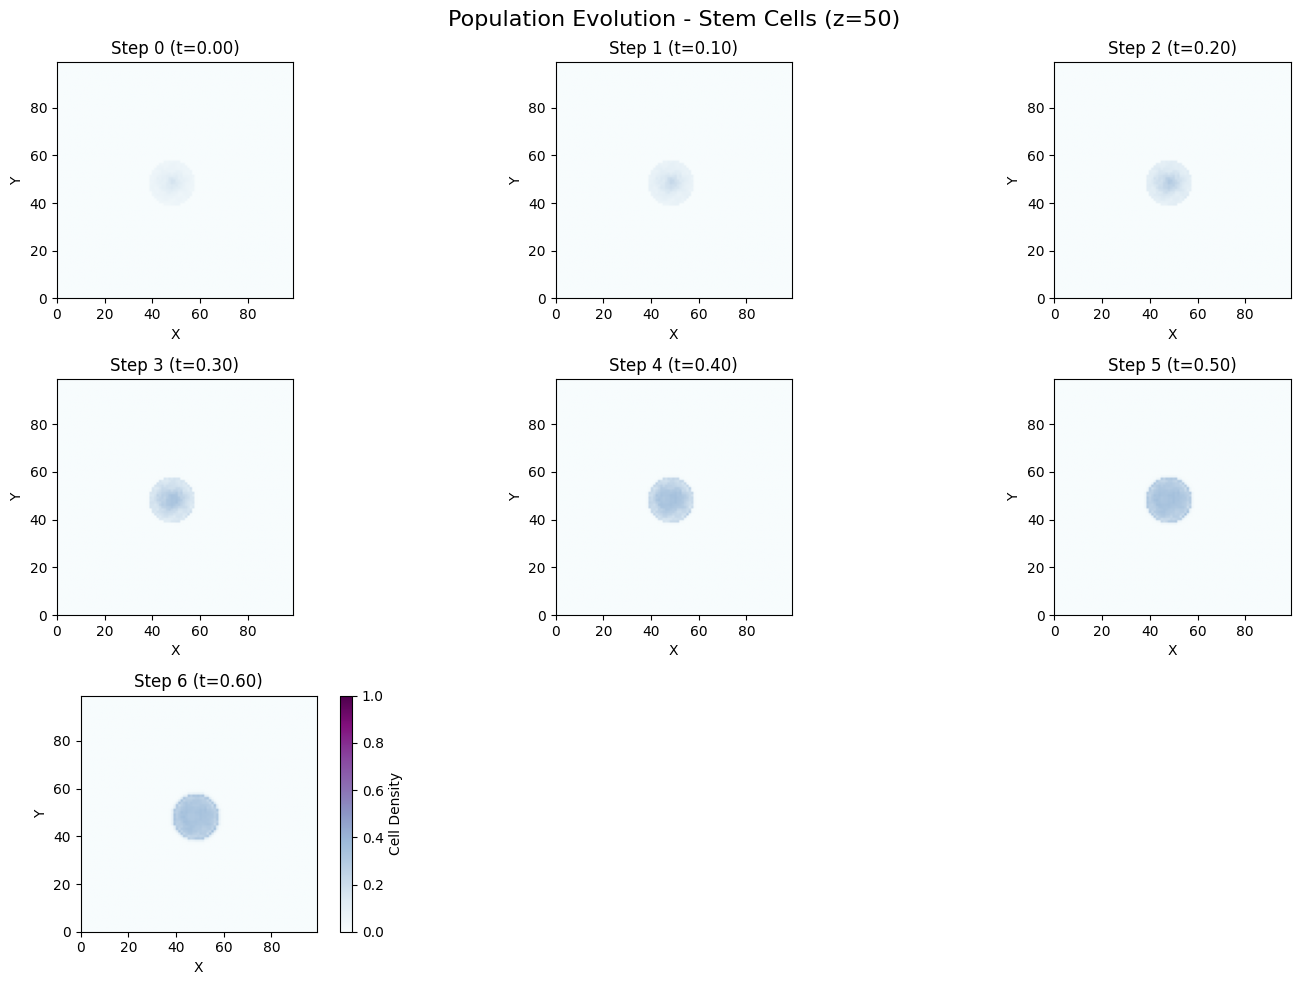

In [15]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Stem Cells", cmap="BuPu", show_plot=True)

Plotting evolution for population: Tumour Cells (index: 1)
Available population labels: ['Stem Cells', 'Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 2, 3, 4, 5, 6]


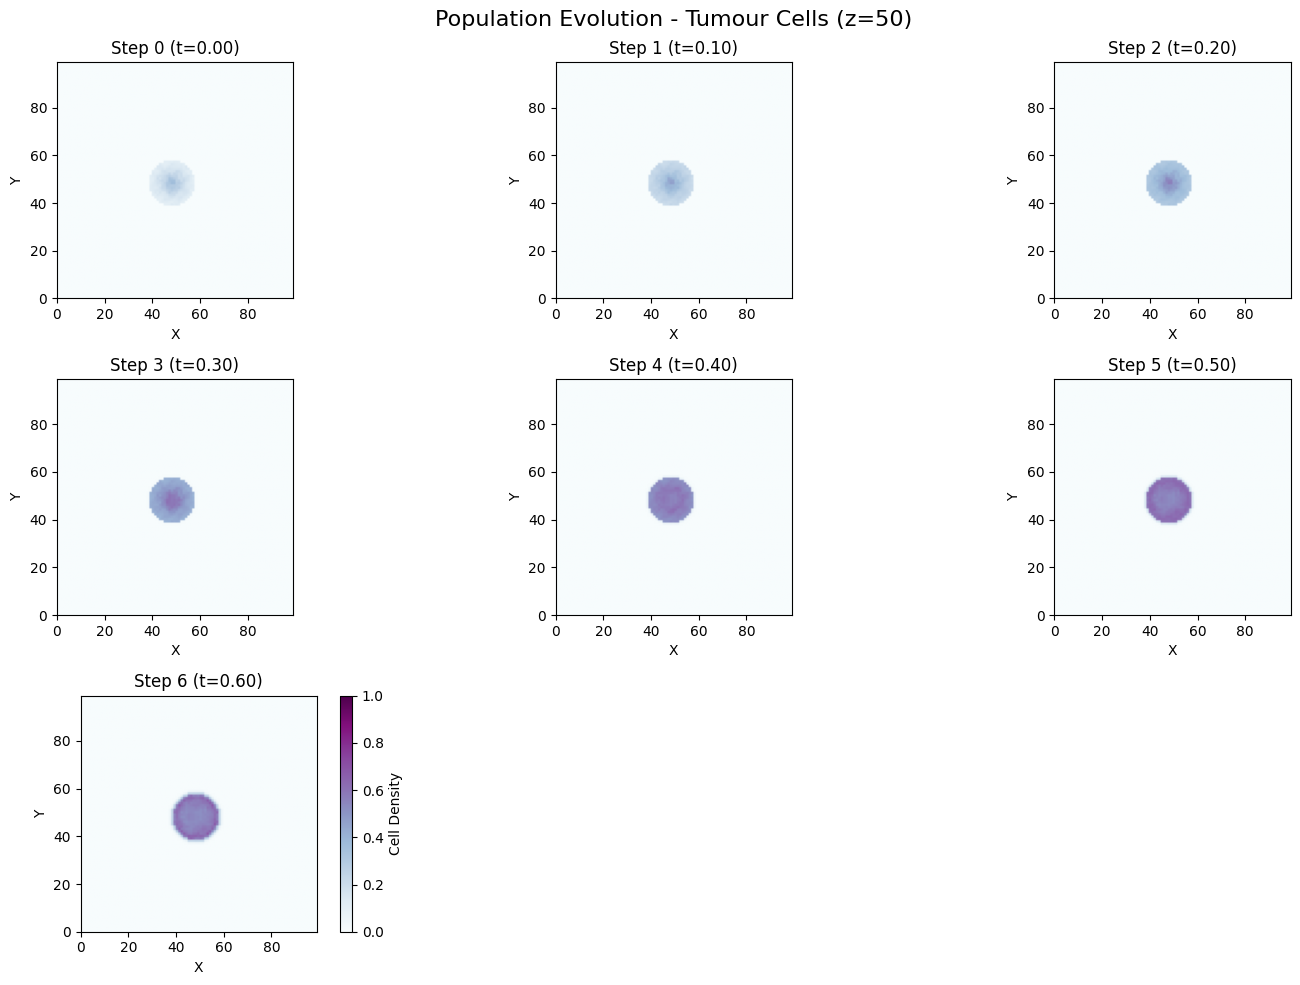

In [16]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Tumour Cells", cmap="BuPu", show_plot=True)

Plotting evolution for population: Necrotic Cells (index: 2)
Available population labels: ['Stem Cells', 'Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 2, 3, 4, 5, 6]


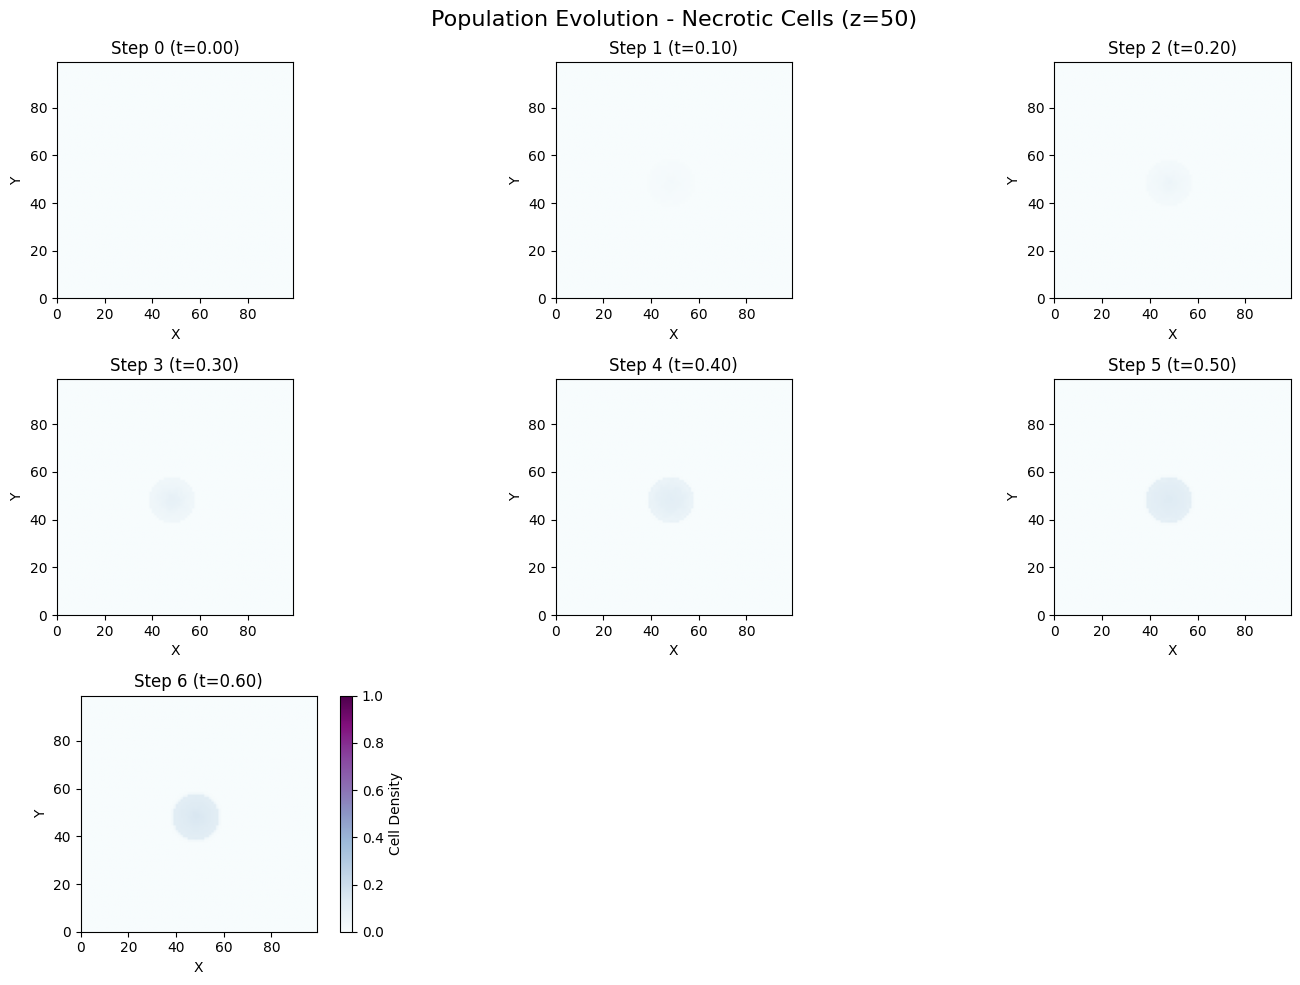

In [17]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Necrotic Cells", cmap="BuPu", show_plot=True)

Creating nutrient field evolution plot...


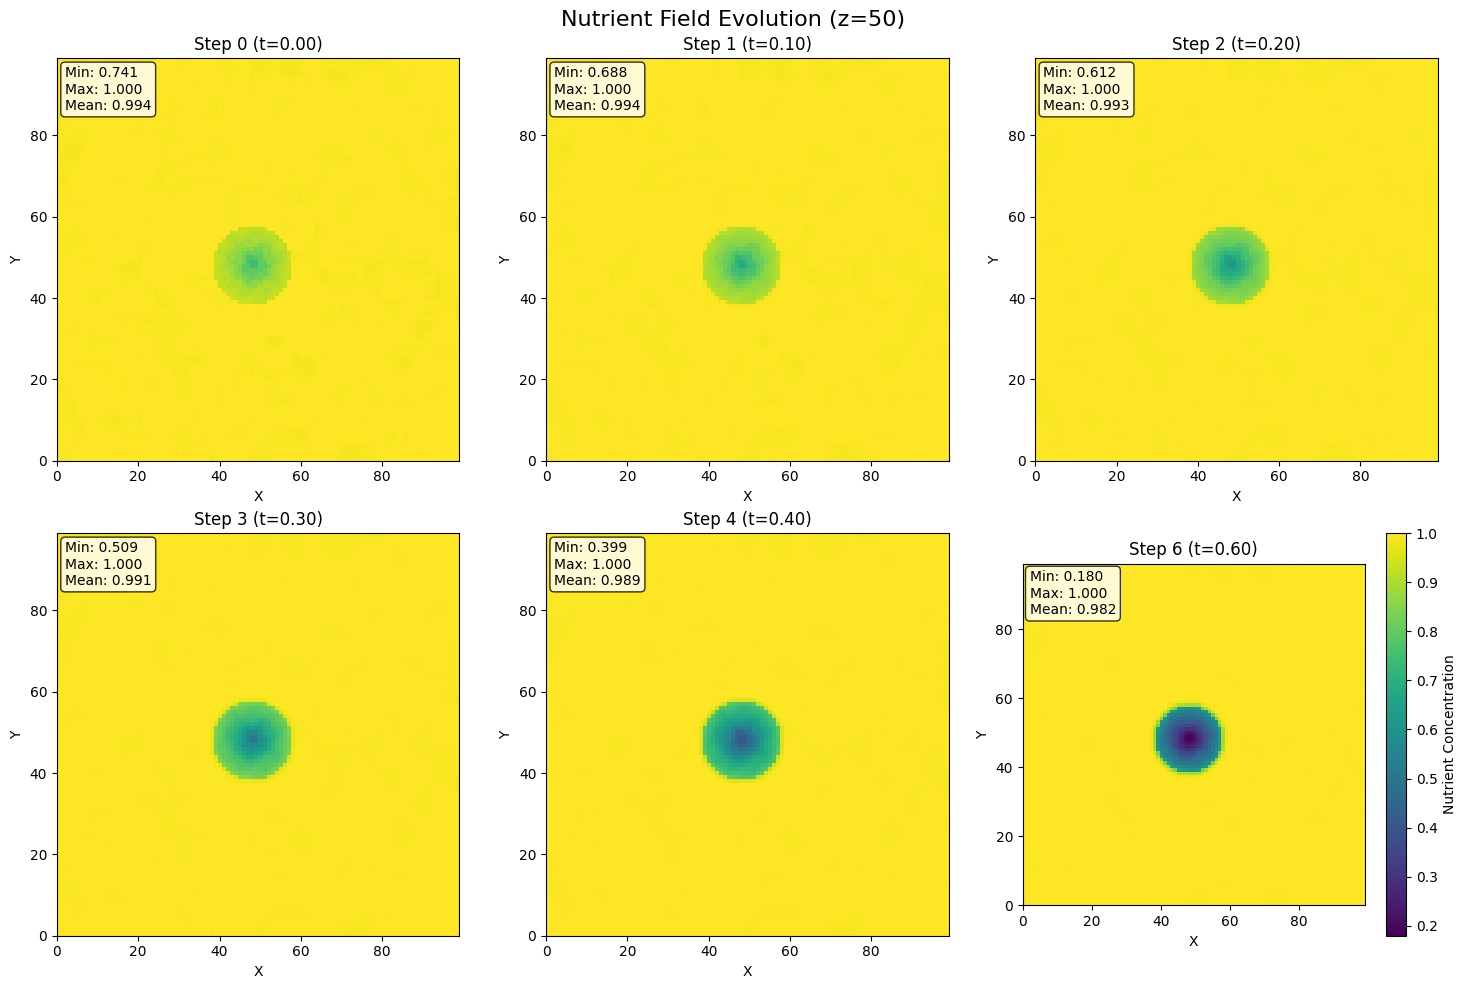

In [18]:
sim_plotter.plot_nutrient_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="viridis", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=True)

Creating source field evolution plot...


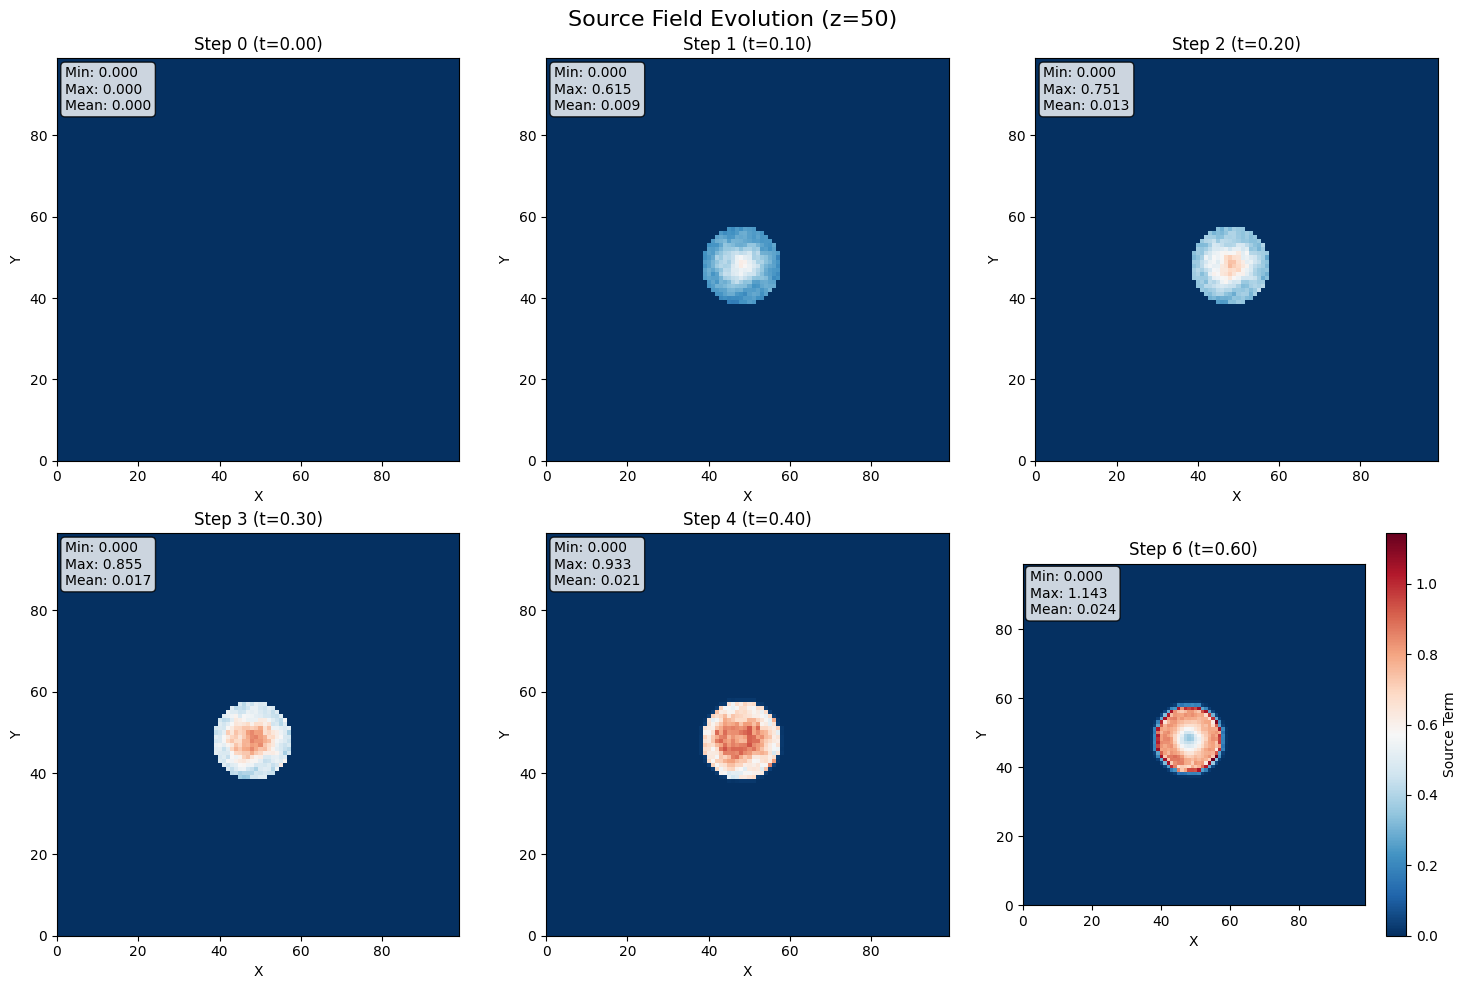

In [19]:
sim_plotter.plot_source_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="RdBu_r", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=True)

## Cell Clumping Analysis

Let's analyze whether cells are clumping or moving towards the center of the simulation domain.


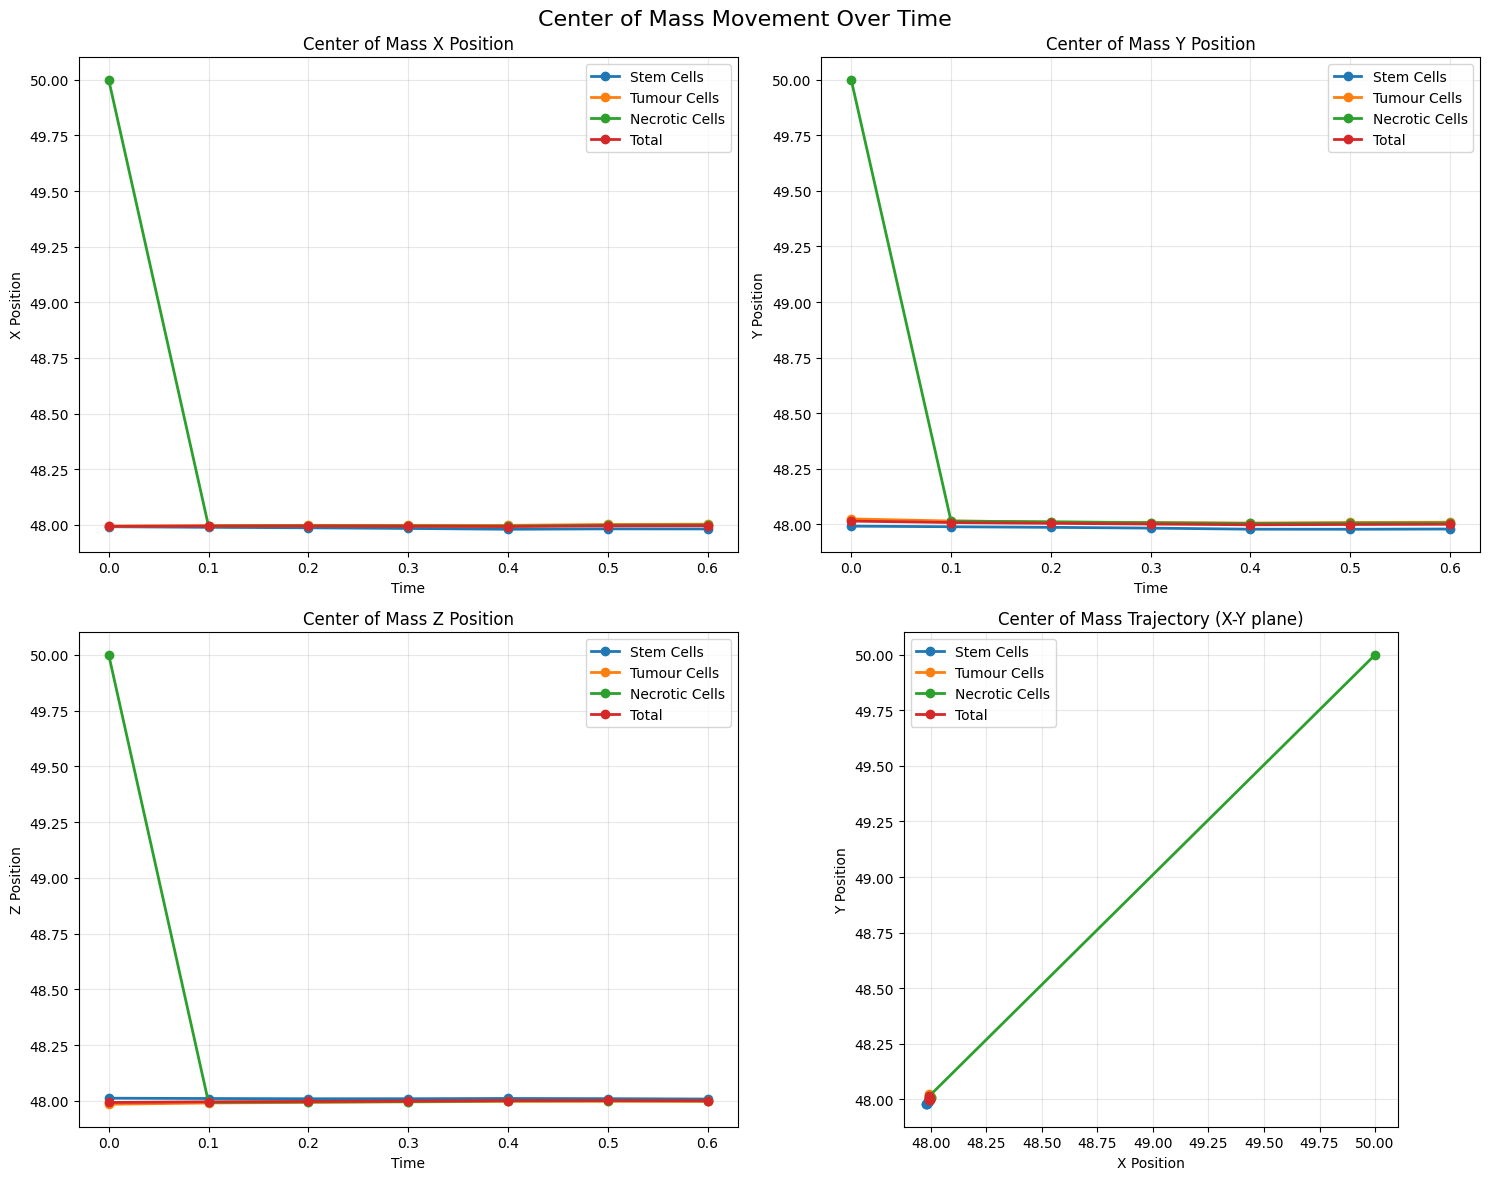

Center of Mass Movement Analysis:

Stem Cells:
  Total displacement: 0.017
  Initial distance from center: 3.467
  Final distance from center: 3.482
  Change in distance from center: 0.016
  → Moving AWAY from center (spreading behavior)

Tumour Cells:
  Total displacement: 0.021
  Initial distance from center: 3.462
  Final distance from center: 3.458
  Change in distance from center: -0.004
  → Moving TOWARDS center (clumping behavior)

Necrotic Cells:
  Total displacement: 3.461
  Initial distance from center: 0.000
  Final distance from center: 3.461
  Change in distance from center: 3.461
  → Moving AWAY from center (spreading behavior)

Total:
  Total displacement: 0.017
  Initial distance from center: 3.463
  Final distance from center: 3.466
  Change in distance from center: 0.002
  → Moving AWAY from center (spreading behavior)


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Analyze center of mass movement over time
def analyze_center_of_mass_movement(simulation_data):
    """Analyze how the center of mass moves over time for each population and total."""
    
    field_data = simulation_data["field_data"]
    saved_times = simulation_data["metadata"]["saved_times"]
    num_populations = simulation_data["metadata"]["num_populations"]
    labels = simulation_data["metadata"].get("population_labels", [f"Population_{i}" for i in range(num_populations)])
    
    # Calculate center of mass for each time step
    com_data = {}
    
    # For each population
    for pop_idx in range(num_populations):
        com_x, com_y, com_z = [], [], []
        for step_idx in range(len(saved_times)):
            phi_hat = field_data["phi_hat"][step_idx]
            com = sim_plotter.utils.calculate_center_of_mass(phi_hat[pop_idx])
            com_x.append(com[0])
            com_y.append(com[1])
            com_z.append(com[2])
        
        com_data[labels[pop_idx]] = {
            'x': np.array(com_x),
            'y': np.array(com_y),
            'z': np.array(com_z),
            'times': np.array(saved_times)
        }
    
    # For total density
    total_com_x, total_com_y, total_com_z = [], [], []
    for step_idx in range(len(saved_times)):
        phi_hat = field_data["phi_hat"][step_idx]
        total_density = np.sum(phi_hat, axis=0)
        com = sim_plotter.utils.calculate_center_of_mass(total_density)
        total_com_x.append(com[0])
        total_com_y.append(com[1])
        total_com_z.append(com[2])
    
    com_data['Total'] = {
        'x': np.array(total_com_x),
        'y': np.array(total_com_y),
        'z': np.array(total_com_z),
        'times': np.array(saved_times)
    }
    
    return com_data

# Run the analysis
com_data = analyze_center_of_mass_movement(simulation_data)

# Plot center of mass movement
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Center of Mass Movement Over Time', fontsize=16)

# Plot X position
ax = axes[0, 0]
for label, data in com_data.items():
    ax.plot(data['times'], data['x'], 'o-', label=label, linewidth=2, markersize=6)
ax.set_xlabel('Time')
ax.set_ylabel('X Position')
ax.set_title('Center of Mass X Position')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Y position
ax = axes[0, 1]
for label, data in com_data.items():
    ax.plot(data['times'], data['y'], 'o-', label=label, linewidth=2, markersize=6)
ax.set_xlabel('Time')
ax.set_ylabel('Y Position')
ax.set_title('Center of Mass Y Position')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot Z position
ax = axes[1, 0]
for label, data in com_data.items():
    ax.plot(data['times'], data['z'], 'o-', label=label, linewidth=2, markersize=6)
ax.set_xlabel('Time')
ax.set_ylabel('Z Position')
ax.set_title('Center of Mass Z Position')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3D trajectory
ax = axes[1, 1]
for label, data in com_data.items():
    ax.plot(data['x'], data['y'], 'o-', label=label, linewidth=2, markersize=6)
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Center of Mass Trajectory (X-Y plane)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Calculate movement statistics
print("Center of Mass Movement Analysis:")
print("=" * 50)

for label, data in com_data.items():
    # Calculate total displacement
    initial_pos = np.array([data['x'][0], data['y'][0], data['z'][0]])
    final_pos = np.array([data['x'][-1], data['y'][-1], data['z'][-1]])
    total_displacement = np.linalg.norm(final_pos - initial_pos)
    
    # Calculate distance from simulation center
    grid_size = simulation_data["metadata"]["grid_size"]
    sim_center = np.array([grid_size[0]/2, grid_size[1]/2, grid_size[2]/2])
    initial_dist_from_center = np.linalg.norm(initial_pos - sim_center)
    final_dist_from_center = np.linalg.norm(final_pos - sim_center)
    
    print(f"\n{label}:")
    print(f"  Total displacement: {total_displacement:.3f}")
    print(f"  Initial distance from center: {initial_dist_from_center:.3f}")
    print(f"  Final distance from center: {final_dist_from_center:.3f}")
    print(f"  Change in distance from center: {final_dist_from_center - initial_dist_from_center:.3f}")
    
    if final_dist_from_center < initial_dist_from_center:
        print(f"  → Moving TOWARDS center (clumping behavior)")
    elif final_dist_from_center > initial_dist_from_center:
        print(f"  → Moving AWAY from center (spreading behavior)")
    else:
        print(f"  → No net movement towards/away from center")


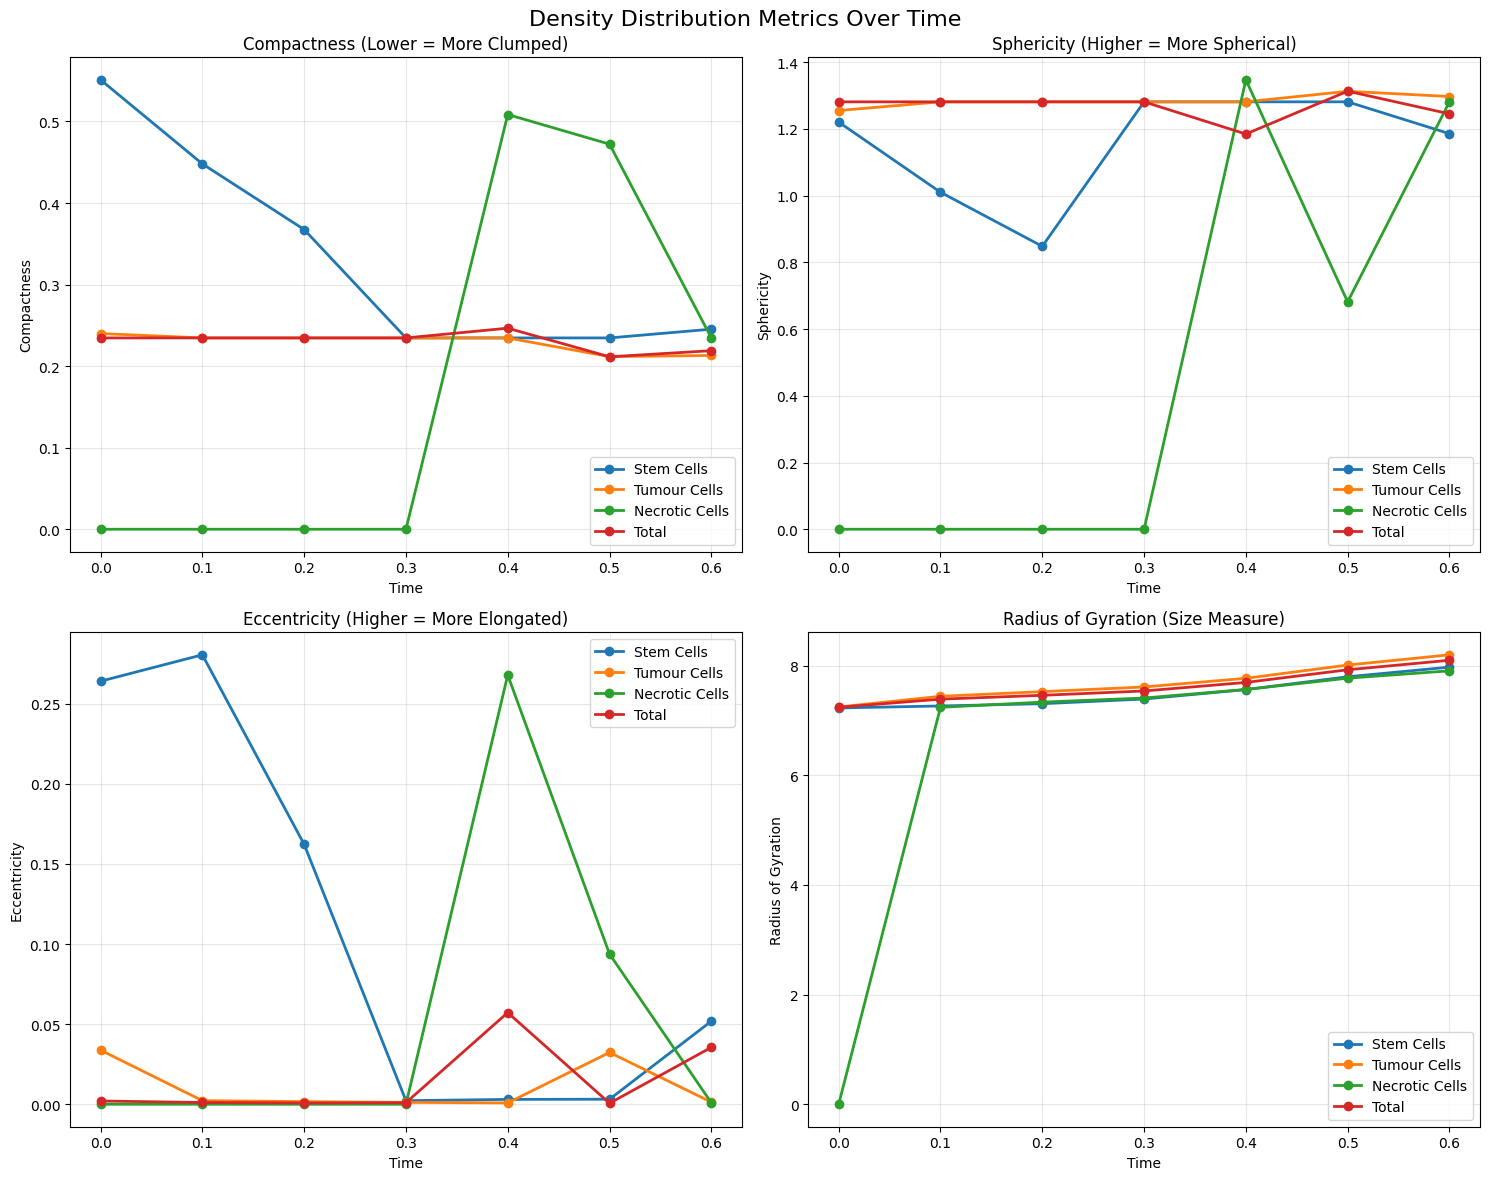


Density Distribution Analysis:

Stem Cells:
  Compactness change: -0.3058 (0.5511 → 0.2453)
  Sphericity change: -0.0347 (1.2202 → 1.1855)
  → Becoming MORE COMPACT (clumping behavior)
  → Becoming LESS SPHERICAL (irregular spreading)

Tumour Cells:
  Compactness change: -0.0269 (0.2400 → 0.2131)
  Sphericity change: 0.0420 (1.2548 → 1.2968)
  → Becoming MORE COMPACT (clumping behavior)
  → Becoming MORE SPHERICAL (uniform clumping)

Necrotic Cells:
  Compactness change: 0.2346 (0.0000 → 0.2346)
  Sphericity change: 1.2809 (0.0000 → 1.2809)
  → Becoming LESS COMPACT (spreading behavior)
  → Becoming MORE SPHERICAL (uniform clumping)

Total:
  Compactness change: -0.0156 (0.2346 → 0.2189)
  Sphericity change: -0.0360 (1.2809 → 1.2449)
  → Becoming MORE COMPACT (clumping behavior)
  → Becoming LESS SPHERICAL (irregular spreading)


In [21]:
# Analyze density distribution and compactness over time
def analyze_density_distribution(simulation_data):
    """Analyze how density distribution changes over time to detect clumping."""
    
    field_data = simulation_data["field_data"]
    saved_times = simulation_data["metadata"]["saved_times"]
    num_populations = simulation_data["metadata"]["num_populations"]
    labels = simulation_data["metadata"].get("population_labels", [f"Population_{i}" for i in range(num_populations)])
    
    # Calculate various metrics over time
    metrics = {}
    
    for pop_idx in range(num_populations):
        label = labels[pop_idx]
        metrics[label] = {
            'compactness': [],
            'sphericity': [],
            'eccentricity': [],
            'radius_gyration': [],
            'times': saved_times
        }
        
        for step_idx in range(len(saved_times)):
            phi_hat = field_data["phi_hat"][step_idx]
            density_field = phi_hat[pop_idx]
            
            # Calculate shape metrics
            compactness = sim_plotter.utils.calculate_compactness(density_field, threshold=0.1)
            sphericity = sim_plotter.utils.calculate_sphericity(density_field, threshold=0.1)
            eccentricity = sim_plotter.utils.calculate_eccentricity(density_field, threshold=0.1)
            radius_gyration = sim_plotter.utils.calculate_radius(density_field, threshold=0.1, method='gyration')
            
            metrics[label]['compactness'].append(compactness)
            metrics[label]['sphericity'].append(sphericity)
            metrics[label]['eccentricity'].append(eccentricity)
            metrics[label]['radius_gyration'].append(radius_gyration)
    
    # For total density
    metrics['Total'] = {
        'compactness': [],
        'sphericity': [],
        'eccentricity': [],
        'radius_gyration': [],
        'times': saved_times
    }
    
    for step_idx in range(len(saved_times)):
        phi_hat = field_data["phi_hat"][step_idx]
        total_density = np.sum(phi_hat, axis=0)
        
        compactness = sim_plotter.utils.calculate_compactness(total_density, threshold=0.1)
        sphericity = sim_plotter.utils.calculate_sphericity(total_density, threshold=0.1)
        eccentricity = sim_plotter.utils.calculate_eccentricity(total_density, threshold=0.1)
        radius_gyration = sim_plotter.utils.calculate_radius(total_density, threshold=0.1, method='gyration')
        
        metrics['Total']['compactness'].append(compactness)
        metrics['Total']['sphericity'].append(sphericity)
        metrics['Total']['eccentricity'].append(eccentricity)
        metrics['Total']['radius_gyration'].append(radius_gyration)
    
    return metrics

# Run the analysis
density_metrics = analyze_density_distribution(simulation_data)

# Plot density distribution metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Density Distribution Metrics Over Time', fontsize=16)

# Plot compactness (lower = more compact/clumped)
ax = axes[0, 0]
for label, data in density_metrics.items():
    ax.plot(data['times'], data['compactness'], 'o-', label=label, linewidth=2, markersize=6)
ax.set_xlabel('Time')
ax.set_ylabel('Compactness')
ax.set_title('Compactness (Lower = More Clumped)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot sphericity (higher = more spherical)
ax = axes[0, 1]
for label, data in density_metrics.items():
    ax.plot(data['times'], data['sphericity'], 'o-', label=label, linewidth=2, markersize=6)
ax.set_xlabel('Time')
ax.set_ylabel('Sphericity')
ax.set_title('Sphericity (Higher = More Spherical)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot eccentricity (higher = more elongated)
ax = axes[1, 0]
for label, data in density_metrics.items():
    ax.plot(data['times'], data['eccentricity'], 'o-', label=label, linewidth=2, markersize=6)
ax.set_xlabel('Time')
ax.set_ylabel('Eccentricity')
ax.set_title('Eccentricity (Higher = More Elongated)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot radius of gyration
ax = axes[1, 1]
for label, data in density_metrics.items():
    ax.plot(data['times'], data['radius_gyration'], 'o-', label=label, linewidth=2, markersize=6)
ax.set_xlabel('Time')
ax.set_ylabel('Radius of Gyration')
ax.set_title('Radius of Gyration (Size Measure)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze clumping behavior
print("\nDensity Distribution Analysis:")
print("=" * 50)

for label, data in density_metrics.items():
    initial_compactness = data['compactness'][0]
    final_compactness = data['compactness'][-1]
    compactness_change = final_compactness - initial_compactness
    
    initial_sphericity = data['sphericity'][0]
    final_sphericity = data['sphericity'][-1]
    sphericity_change = final_sphericity - initial_sphericity
    
    print(f"\n{label}:")
    print(f"  Compactness change: {compactness_change:.4f} ({initial_compactness:.4f} → {final_compactness:.4f})")
    print(f"  Sphericity change: {sphericity_change:.4f} ({initial_sphericity:.4f} → {final_sphericity:.4f})")
    
    # Interpret clumping behavior
    if compactness_change < -0.01:  # Significant decrease in compactness
        print(f"  → Becoming MORE COMPACT (clumping behavior)")
    elif compactness_change > 0.01:  # Significant increase in compactness
        print(f"  → Becoming LESS COMPACT (spreading behavior)")
    else:
        print(f"  → No significant change in compactness")
    
    if sphericity_change > 0.01:  # Significant increase in sphericity
        print(f"  → Becoming MORE SPHERICAL (uniform clumping)")
    elif sphericity_change < -0.01:  # Significant decrease in sphericity
        print(f"  → Becoming LESS SPHERICAL (irregular spreading)")
    else:
        print(f"  → No significant change in sphericity")


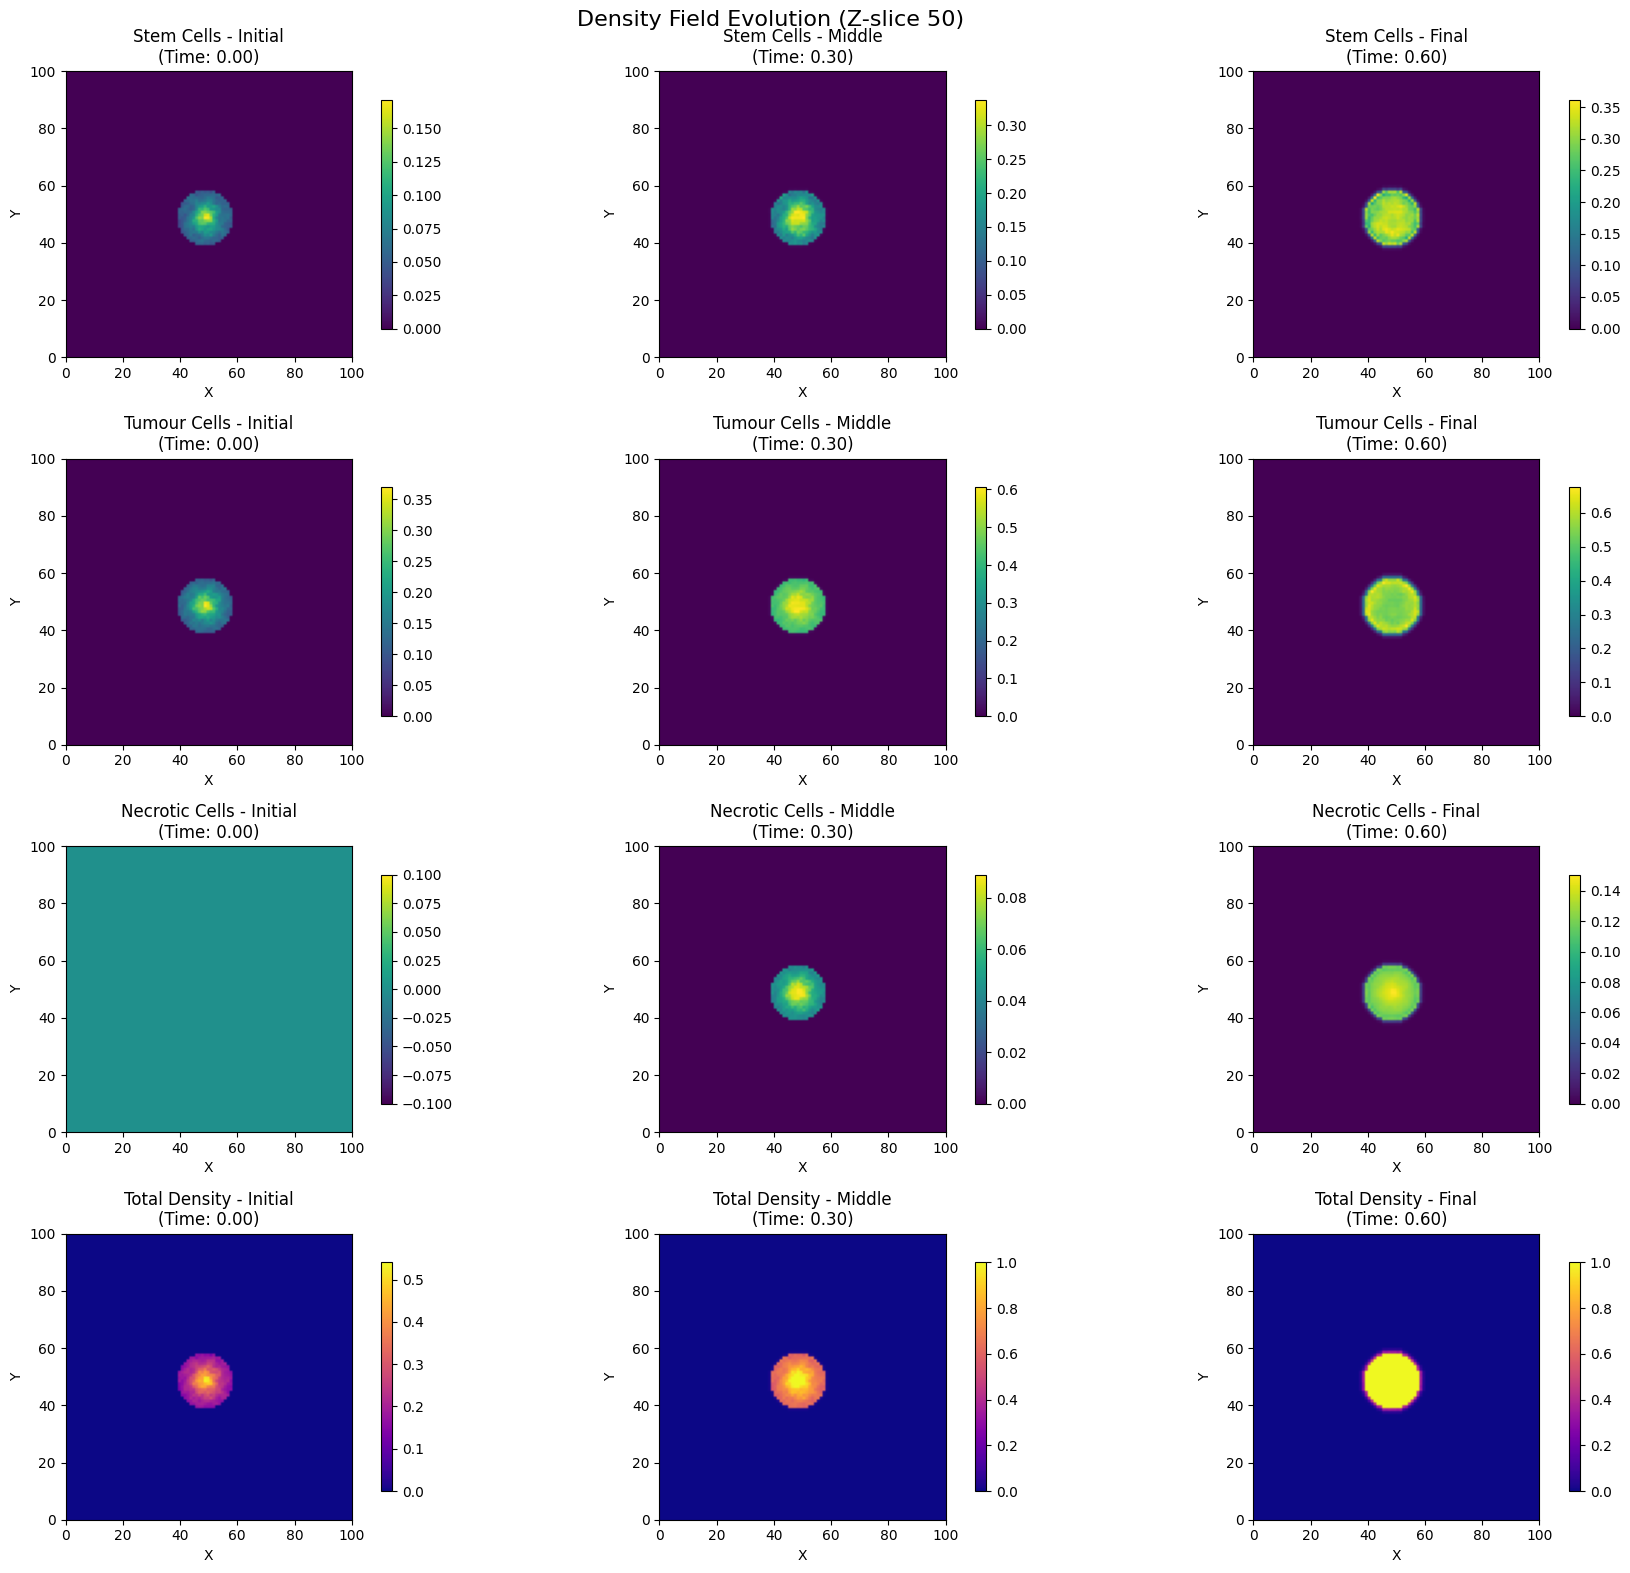


SUMMARY: CELL CLUMPING ANALYSIS

Based on the analysis above, here are the key findings:

1. CENTER OF MASS MOVEMENT:
   - Check the center of mass movement plots above
   - Look for populations moving towards the simulation center
   - Negative 'Change in distance from center' indicates clumping

2. DENSITY DISTRIBUTION METRICS:
   - Decreasing compactness indicates clumping behavior
   - Increasing sphericity indicates uniform clumping
   - Check the density distribution plots above

3. VISUAL INSPECTION:
   - Compare the density field evolution plots
   - Look for cells concentrating in central regions
   - Check for formation of dense clusters

4. INTERPRETATION:
   - Clumping behavior suggests attractive cell-cell interactions
   - This could be due to adhesion forces or chemotaxis
   - May indicate the need to adjust model parameters

If clumping is observed, consider:
   - Reducing cell-cell adhesion parameters
   - Increasing repulsive forces
   - Adjusting nutrient field effe

In [22]:
# Visualize density fields at key time points to see clumping behavior
def visualize_density_evolution(simulation_data, z_slice=None):
    """Create a visual comparison of density fields at different time points."""
    
    field_data = simulation_data["field_data"]
    saved_times = simulation_data["metadata"]["saved_times"]
    num_populations = simulation_data["metadata"]["num_populations"]
    labels = simulation_data["metadata"].get("population_labels", [f"Population_{i}" for i in range(num_populations)])
    
    # Select time points to visualize (first, middle, last)
    time_indices = [0, len(saved_times)//2, len(saved_times)-1]
    time_labels = ['Initial', 'Middle', 'Final']
    
    # Set z_slice to middle if not provided
    if z_slice is None:
        grid_size = simulation_data["metadata"]["grid_size"]
        z_slice = grid_size[2] // 2
    
    # Create subplots for each population and time point
    fig, axes = plt.subplots(num_populations + 1, 3, figsize=(18, 4 * (num_populations + 1)))
    fig.suptitle(f'Density Field Evolution (Z-slice {z_slice})', fontsize=16)
    
    # Plot each population
    for pop_idx in range(num_populations):
        label = labels[pop_idx]
        
        for time_idx, (step_idx, time_label) in enumerate(zip(time_indices, time_labels)):
            ax = axes[pop_idx, time_idx]
            
            phi_hat = field_data["phi_hat"][step_idx]
            density_slice = phi_hat[pop_idx][:, :, z_slice]
            
            im = ax.imshow(density_slice.T, origin='lower', cmap='viridis', 
                          extent=[0, density_slice.shape[0], 0, density_slice.shape[1]])
            ax.set_title(f'{label} - {time_label}\n(Time: {saved_times[step_idx]:.2f})')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            
            # Add colorbar
            plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Plot total density
    for time_idx, (step_idx, time_label) in enumerate(zip(time_indices, time_labels)):
        ax = axes[num_populations, time_idx]
        
        phi_hat = field_data["phi_hat"][step_idx]
        total_density = np.sum(phi_hat, axis=0)
        density_slice = total_density[:, :, z_slice]
        
        im = ax.imshow(density_slice.T, origin='lower', cmap='plasma', 
                      extent=[0, density_slice.shape[0], 0, density_slice.shape[1]])
        ax.set_title(f'Total Density - {time_label}\n(Time: {saved_times[step_idx]:.2f})')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_density_evolution(simulation_data)

# Summary of clumping analysis
print("\n" + "="*60)
print("SUMMARY: CELL CLUMPING ANALYSIS")
print("="*60)

print("\nBased on the analysis above, here are the key findings:")
print("\n1. CENTER OF MASS MOVEMENT:")
print("   - Check the center of mass movement plots above")
print("   - Look for populations moving towards the simulation center")
print("   - Negative 'Change in distance from center' indicates clumping")

print("\n2. DENSITY DISTRIBUTION METRICS:")
print("   - Decreasing compactness indicates clumping behavior")
print("   - Increasing sphericity indicates uniform clumping")
print("   - Check the density distribution plots above")

print("\n3. VISUAL INSPECTION:")
print("   - Compare the density field evolution plots")
print("   - Look for cells concentrating in central regions")
print("   - Check for formation of dense clusters")

print("\n4. INTERPRETATION:")
print("   - Clumping behavior suggests attractive cell-cell interactions")
print("   - This could be due to adhesion forces or chemotaxis")
print("   - May indicate the need to adjust model parameters")

print("\nIf clumping is observed, consider:")
print("   - Reducing cell-cell adhesion parameters")
print("   - Increasing repulsive forces")
print("   - Adjusting nutrient field effects")
print("   - Modifying boundary conditions")
